In [5]:
# 데이터 불러오기

import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/Colab Notebooks/diabetes.csv'
df = pd.read_csv(path)

In [6]:
# 데이터 출력해서 확인
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
#label, feature 데이터 입력하

y=df['Outcome']

X=df.drop('Outcome',axis=1)

In [8]:
y.value_counts()
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [9]:
# numpy 변환
X = X.values # 엑셀 형태 → 숫자 배열로 변환하기 위해 사

# 정규화 (데이터를 비슷한 범위로 맞추는 작업)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [11]:
from tensorflow.keras import layers, models
# 층(layer)을 순서대로 쌓는 모델, 입력 → 은닉층 → 출력층으로 일직선 구조

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)), # 첫 번째 층 (입력층 + 은닉층),
    # 뉴런(노드) 64개, 입력 데이터의 컬럼 개수, activation="relu" <- 활성화 함수
    layers.Dropout(0.3), # 30% 뉴런을 랜덤으로 off > 과적합 방지
    layers.Dense(32, activation="relu"),# 두 번째 은닉층, 뉴런을 64 → 32로 줄이면서 중요한 정보만 남김
    layers.Dense(1, activation="sigmoid")
    # Y.shape[1] = 클래스 개수, softmax = 확률로 변환
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# 컴파일
model.compile(
    optimizer="adam", # 가중치 업데이트 방법, 자동으로 학습률 조정
    loss="binary_crossentropy",
    metrics=["accuracy"] # 정확도 측정
)

In [13]:
# 모델학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2, # 학습 데이터 중 20%를 검증용으로 사용
    epochs=50, # 전체 데이터를 50번 반복 학습
    batch_size=16, # 한 번에 16개씩 학습
    verbose=1 # 학습 과정 출력
)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6087 - loss: 0.6585 - val_accuracy: 0.7586 - val_loss: 0.5784
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7109 - loss: 0.5801 - val_accuracy: 0.7845 - val_loss: 0.5216
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7522 - loss: 0.5338 - val_accuracy: 0.7931 - val_loss: 0.4898
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7457 - loss: 0.5088 - val_accuracy: 0.7931 - val_loss: 0.4748
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7652 - loss: 0.5020 - val_accuracy: 0.8017 - val_loss: 0.4686
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7848 - loss: 0.4875 - val_accuracy: 0.8103 - val_loss: 0.4640
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7870 - loss: 0.4785 - val_accuracy: 0.8190 - val_loss: 0.4648
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7696 - loss: 0.4699 - val_accuracy: 0.8190 - val_loss

In [14]:

y_pred = model.predict(X_test) # 결과 = 확률
y_pred_class = (y_pred >= 0.5).astype(int).flatten()
y_test_class = y_test

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [15]:
# 그래프 그리기용 데이터 저장
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']


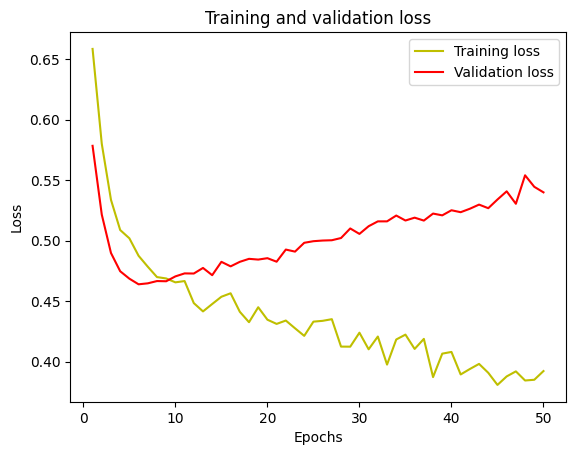

In [16]:
# 학습 과정에서 손실(loss)이 어떻게 변하는지 시각화

import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss'] # loss = 훈련 데이터 오차 /
val_loss = history.history['val_loss'] # val_loss = 검증 데이터 오차
# history는 model.fit() 결과
epochs = range(1, len(loss) + 1) # x축 만들기

plt.plot(epochs, loss, 'y', label='Training loss') # 훈련 데이터 손실
# x축: epoch y축: loss 'y': 노란색
plt.plot(epochs, val_loss, 'r', label='Validation loss') # 검증 데이터 손실
# 'r': 빨간색
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


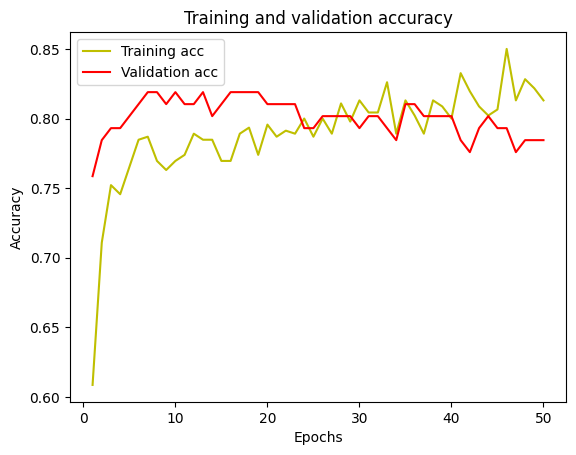

In [17]:
acc = history.history['accuracy'] # 훈련 데이터 정확도
val_acc = history.history['val_accuracy'] # 검증 데이터 정확도
plt.plot(epochs, acc, 'y', label='Training acc') # 훈련 정확도 (노란색)
plt.plot(epochs, val_acc, 'r', label='Validation acc') # 검증 정확도 (빨간색)
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [18]:

from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       130
           1       0.71      0.68      0.69        62

    accuracy                           0.81       192
   macro avg       0.78      0.77      0.78       192
weighted avg       0.81      0.81      0.81       192

[[113  17]
 [ 20  42]]
